In [25]:
# 26.08.2026 - JEDEN dedykowany watek (na wyrazna prosbe Maćka - odzielny
# notebook, nie doklejony do 20260826a.ipynb): kompletnosc/jakosc danych CR
# per stacja NMDB, o co explicite prosil Homola na spotkaniu 24.08 (patrz
# project_homola_review_feedback.md w pamieci Claude'a, punkt 4).
#
# ZAKRES CELOWO OGRANICZONY: ten notebook liczy TYLKO obiektywne miary
# kompletnosci/jakosci (zasieg dat, % wypelnienia siatki 6h, dziury,
# zrodlo pliku). NIE probuje jeszcze odpowiedziec na pytanie Homoli #5
# ("dlaczego niektore stacje sa wyblakle na heatmapach 20260822f.ipynb") -
# to zostaje na pozniej, na wyrazna prosbe Maćka (26.08: "to moze byc
# potem").
#
# Dane i loadery skopiowane 1:1 z 20260822c.ipynb (ten sam kod, ktory
# faktycznie zasilal skan cykl-do-cyklu) - zeby kompletnosc byla liczona
# na DOKLADNIE tych samych szeregach, ktore wchodzily do analizy, a nie na
# jakiejs innej/nowej wersji danych.
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

RESULTS_DIR = "../results"
MOSC_PATH = "../data/mosc_data.csv"
OULU_PATH = "../data/oulu_5min_data.csv"
EXTENDED_DIR = "../data/csv_data_stations_extended"
FULL6H_DIR = "../data/csv_data_stations_full6h"

# 20 stacji "pozostalych" + przyblizony PIERWSZY ROK danych wg sondy NMDB
# allstations (20.08, roczna rozdzielczosc) - kopiowane z
# download_stations_extended_history.py. Uzywane tu jako oczekiwanie do
# porownania z faktycznie znalezionym pierwszym pomiarem (patrz krok 2).
STATION_FIRST_YEAR = {
    "THUL": 1957, "LMKS": 1981, "APTY": 2000, "SOPB": 1997,
    "JUNG1": 1986, "SOPO": 1964, "FSMT": 2000, "JUNG": 1958,
    "NEWK": 1964, "PWNK": 2000, "MXCO": 1990, "NAIN": 2000, "HRMS": 1957,
    "TERA": 1968, "INVK": 2000, "ATHN": 2000, "AATB": 1973, "PSNM": 2007,
    "NANM": 1997, "MCRL": 1950,
}
OTHER_STATIONS = list(STATION_FIRST_YEAR.keys())

# Granice cykli - identyczne jak 20260822d/23a/24a/26a.ipynb - uzyte tu do
# rozbicia kompletnosci per (stacja, cykl), nie tylko per stacja globalnie.
CYCLE_BOUNDS = {
    "cycle_1964": ("1965-01-01", "1976-02-01"),
    "cycle_1976": ("1976-02-01", "1986-05-01"),
    "cycle_1986": ("1986-05-01", "1996-06-01"),
    "cycle_1996": ("1996-06-01", "2008-11-01"),
    "cycle_2008": ("2008-11-01", "2019-09-01"),
    "cycle_2019_incomplete": ("2019-09-01", "2025-01-31"),
}
CYCLE_START = {c: pd.Timestamp(s) for c, (s, e) in CYCLE_BOUNDS.items()}
CYCLE_END = {c: pd.Timestamp(e) for c, (s, e) in CYCLE_BOUNDS.items()}

In [26]:
# Loadery CR - identyczne z 20260822c.ipynb (funkcja load_station() z
# fallbackiem extended -> full6h). mosc/oulu maja wlasne dedykowane pliki
# pelnej historii (jak zawsze w tym repo). Dla oulu trzymamy OSOBNO wersje
# natywna (5 min) - do policzenia prawdziwej kompletnosci u zrodla - i
# wersje resample("6h") - to, co faktycznie wchodzi do skanu.
def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_oulu_native():
    # UWAGA: jeden uszkodzony wiersz (linia 839815, ~15-dniowa luka 1978) -
    # patrz CLAUDE.md - pomijany przez errors="coerce" + dropna, jak
    # wszedzie indziej w tym repo.
    df = pd.read_csv(OULU_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    n_bad = df["datetime"].isna().sum()
    if n_bad:
        print(f"load_oulu_native: pominieto {n_bad} niesparsowalnych wierszy (uszkodzone dane)")
    df = df.dropna(subset=["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_station(station):
    ext_path = os.path.join(EXTENDED_DIR, f"{station.lower()}_extended_6h.csv")
    full_path = os.path.join(FULL6H_DIR, f"{station.lower()}_full_6h.csv")
    if os.path.exists(ext_path):
        path, source = ext_path, "extended (pelna historia)"
    elif os.path.exists(full_path):
        path, source = full_path, "full6h (TYLKO 2005-2025)"
    else:
        return None, None
    df = pd.read_csv(path)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"], source


cr_series = {}
source_used = {}

cr_series["mosc"] = load_mosc()
source_used["mosc"] = "dedykowany plik (natywne 6h, 1960-2025)"

oulu_native = load_oulu_native()
cr_series["oulu"] = oulu_native.resample("6h").mean()
source_used["oulu"] = "dedykowany plik (natywne 5 min -> resample 6h, 1970-2025)"

for station in OTHER_STATIONS:
    s, source = load_station(station)
    if s is None:
        print(f"{station.lower()}: BRAK pliku danych, pomijam")
        continue
    cr_series[station.lower()] = s
    source_used[station.lower()] = source

print(f"Wczytano {len(cr_series)} stacji.")
for name, s in cr_series.items():
    print(f"  {name}: {len(s)} pomiarow, {s.index.min()} .. {s.index.max()} ({source_used[name]})")

load_oulu_native: pominieto 1 niesparsowalnych wierszy (uszkodzone dane)
Wczytano 22 stacji.
  mosc: 91824 pomiarow, 1960-01-01 00:00:00 .. 2025-03-23 18:00:00 (dedykowany plik (natywne 6h, 1960-2025))
  oulu: 81816 pomiarow, 1970-01-01 00:00:00 .. 2025-12-31 18:00:00 (dedykowany plik (natywne 5 min -> resample 6h, 1970-2025))
  thul: 96178 pomiarow, 1957-08-13 12:00:00 .. 2025-12-31 18:00:00 (extended (pelna historia))
  lmks: 60784 pomiarow, 1981-12-01 00:00:00 .. 2023-07-10 18:00:00 (extended (pelna historia))
  apty: 37234 pomiarow, 2000-07-01 00:00:00 .. 2025-12-31 18:00:00 (extended (pelna historia))
  sopb: 29044 pomiarow, 1997-12-31 00:00:00 .. 2025-12-31 18:00:00 (extended (pelna historia))
  jung1: 57538 pomiarow, 1986-01-01 00:00:00 .. 2025-12-31 18:00:00 (extended (pelna historia))
  sopo: 80347 pomiarow, 1964-03-01 00:00:00 .. 2025-12-31 18:00:00 (extended (pelna historia))
  fsmt: 36703 pomiarow, 2000-10-04 00:00:00 .. 2025-12-31 18:00:00 (extended (pelna historia))
  jun

In [27]:
# KROK 2: miary kompletnosci per stacja, na siatce docelowej 6h (dokladnie
# ta rozdzielczosc wchodzi do cosmoseismic_stat we wszystkich skanach tego
# repo - mosc/inne stacje natywnie, oulu po resamplingu). Definicje:
#   - completeness_pct = 100 * (liczba NIE-NaN pomiarow) / (oczekiwana
#     liczba probek co 6h w zasiegu [t_min, t_max])
#   - dziura = odstep miedzy kolejnymi NIE-NaN pomiarami > 2x oczekiwanego
#     kroku (12h) - liczymy n_gaps, najdluzsza dziura (dni) i sume dziur
#   - dla wiekszosci stacji NaN nie powinno wystapic w ogole (dane
#     pobierane juz w 6h z NMDB, bez resamplingu) - NaN > 0 tam oznaczaloby
#     cos wartego sprawdzenia osobno; dla oulu NaN to normalny efekt
#     resamplingu przez luki w natywnych 5-minutowych danych.
RESOLUTION_HOURS = 6


def completeness_report(name, raw_series):
    valid = raw_series.dropna()
    n_nan = len(raw_series) - len(valid)
    if len(valid) == 0:
        return dict(station=name, n_points=0, n_nan=n_nan, t_min=pd.NaT, t_max=pd.NaT,
                    span_years=np.nan, expected_n=0, completeness_pct=np.nan,
                    n_gaps=0, longest_gap_days=np.nan, total_gap_days=np.nan)

    t_min, t_max = valid.index.min(), valid.index.max()
    span_days = (t_max - t_min).total_seconds() / 86400
    expected_n = int(span_days * 24 / RESOLUTION_HOURS) + 1

    diffs = valid.index.to_series().diff().dropna()
    gap_threshold = pd.Timedelta(hours=RESOLUTION_HOURS * 2)
    gaps = diffs[diffs > gap_threshold]

    return dict(
        station=name, n_points=len(valid), n_nan=n_nan, t_min=t_min, t_max=t_max,
        span_years=span_days / 365.25, expected_n=expected_n,
        completeness_pct=100 * len(valid) / expected_n if expected_n else np.nan,
        n_gaps=len(gaps),
        longest_gap_days=gaps.max().total_seconds() / 86400 if len(gaps) else 0.0,
        total_gap_days=gaps.sum().total_seconds() / 86400 if len(gaps) else 0.0,
    )


completeness_rows = [completeness_report(name, s) for name, s in cr_series.items()]
completeness = pd.DataFrame(completeness_rows)
completeness["source"] = completeness["station"].map(source_used)
completeness["nominal_first_year"] = completeness["station"].map(
    {k.lower(): v for k, v in STATION_FIRST_YEAR.items()}
)
completeness["actual_first_year"] = completeness["t_min"].dt.year
completeness["years_shorter_than_nominal"] = (
    completeness["actual_first_year"] - completeness["nominal_first_year"]
)

completeness = completeness.sort_values("completeness_pct", ascending=False)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 30)
print(completeness.to_string(index=False))
completeness.to_csv(f"{RESULTS_DIR}/station_data_completeness.csv", index=False)

station  n_points  n_nan               t_min               t_max  span_years  expected_n  completeness_pct  n_gaps  longest_gap_days  total_gap_days                                                    source  nominal_first_year  actual_first_year  years_shorter_than_nominal
   lmks     60784      0 1981-12-01 00:00:00 2023-07-10 18:00:00   41.606434       60788         99.993420       1              1.25            1.25                                 extended (pelna historia)              1981.0               1981                         0.0
   apty     37234      0 2000-07-01 00:00:00 2025-12-31 18:00:00   25.502396       37260         99.930220       8              1.50            8.00                                 extended (pelna historia)              2000.0               2000                         0.0
   fsmt     36703      0 2000-10-04 00:00:00 2025-12-31 18:00:00   25.242300       36880         99.520065      23              9.25           47.25                              

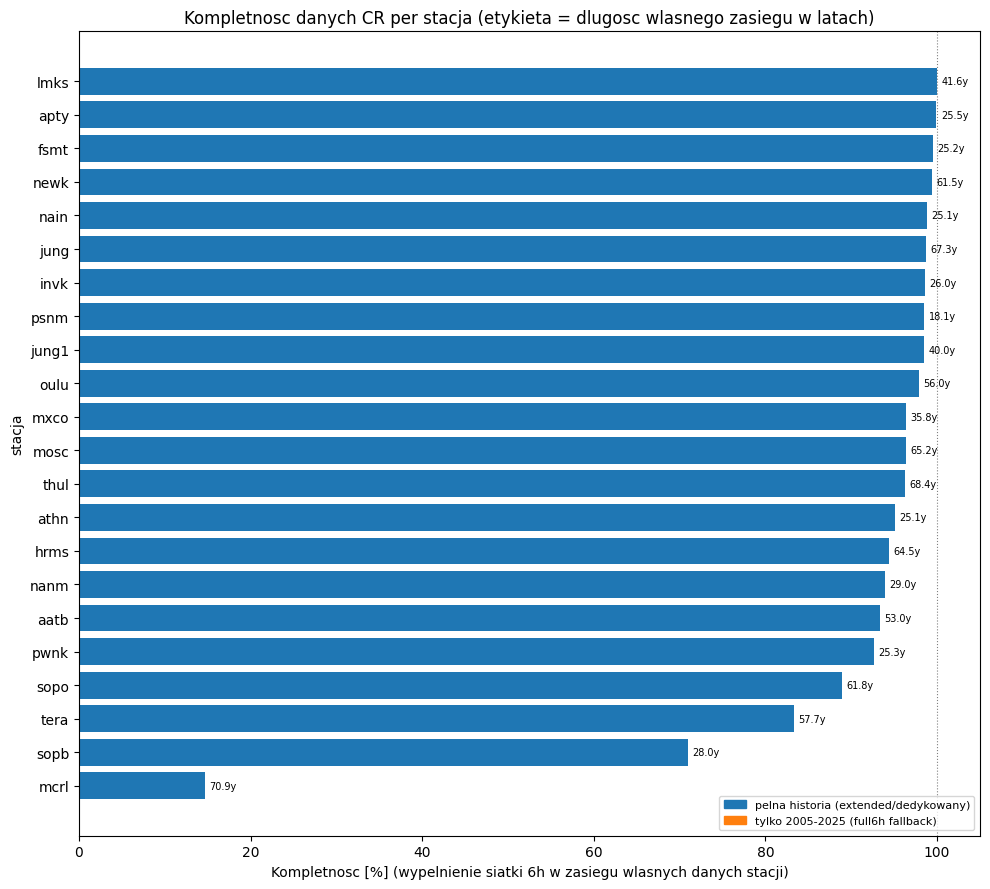

In [28]:
# KROK 3: wizualizacja - wykres slupkowy completeness_pct per stacja
# (posortowane), kolor = kategoria zrodla (pelna historia vs tylko
# 2005-2025), z zaznaczonym zasiegiem w latach nad kazdym slupkiem.
def source_category(s):
    if "TYLKO 2005-2025" in s:
        return "full6h (tylko 2005-2025)"
    return "pelna historia"


completeness["source_category"] = completeness["source"].map(source_category)
plot_df = completeness.sort_values("completeness_pct", ascending=True)

colors = plot_df["source_category"].map({
    "pelna historia": "tab:blue",
    "full6h (tylko 2005-2025)": "tab:orange",
})

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(plot_df["station"], plot_df["completeness_pct"], color=colors)
for y, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["completeness_pct"] + 0.5, y, f"{row['span_years']:.1f}y", va="center", fontsize=7)

ax.set_xlabel("Kompletnosc [%] (wypelnienie siatki 6h w zasiegu wlasnych danych stacji)")
ax.set_ylabel("stacja")
ax.set_xlim(0, 105)
ax.axvline(100, color="gray", lw=0.8, ls=":")
ax.set_title("Kompletnosc danych CR per stacja (etykieta = dlugosc wlasnego zasiegu w latach)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["tab:blue", "tab:orange"]]
ax.legend(handles, ["pelna historia (extended/dedykowany)", "tylko 2005-2025 (full6h fallback)"],
          loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_data_completeness.png", dpi=120, bbox_inches="tight")
plt.show()

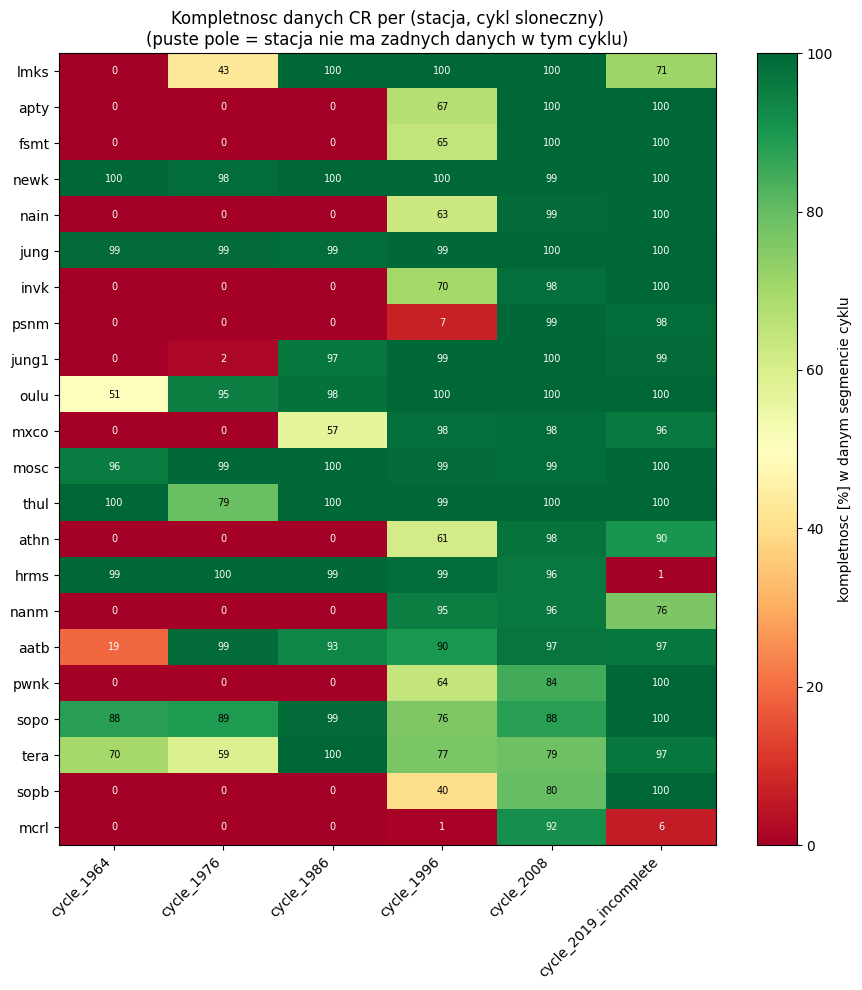

In [29]:
# KROK 4: to samo, ale rozbite per (stacja, cykl sloneczny) - kompletnosc
# globalna (krok 2) moze ukrywac to, ze KONKRETNY cykl uzyty w skanie
# cykl-do-cyklu ma slabe pokrycie, mimo ze reszta historii stacji jest OK
# (i odwrotnie). To bezposrednio tlumaczy, ile realnie "danych" stoi za
# wynikiem danej stacji w danym cyklu w 20260824a.ipynb/20260826a.ipynb.
def completeness_in_window(raw_series, t0, t1):
    valid = raw_series[(raw_series.index >= t0) & (raw_series.index < t1)].dropna()
    span_days = (t1 - t0).total_seconds() / 86400
    expected_n = int(span_days * 24 / RESOLUTION_HOURS)
    return 100 * len(valid) / expected_n if expected_n else np.nan


rows = []
for name, s in cr_series.items():
    for cycle in CYCLE_BOUNDS:
        # UWAGA: CYCLE_START/CYCLE_END (juz przekonwertowane na pd.Timestamp
        # w komorce 0) - NIE surowe stringi z CYCLE_BOUNDS.items(), bo t1-t0
        # na stringach rzuca TypeError.
        rows.append(dict(
            station=name, cycle=cycle,
            completeness_pct=completeness_in_window(s, CYCLE_START[cycle], CYCLE_END[cycle]),
        ))

by_cycle = pd.DataFrame(rows)
by_cycle.to_csv(f"{RESULTS_DIR}/station_data_completeness_by_cycle.csv", index=False)

pivot = by_cycle.pivot(index="station", columns="cycle", values="completeness_pct")
pivot = pivot[list(CYCLE_BOUNDS.keys())]
# sortowanie wierszy po kompletnosci globalnej (krok 2) - najlepsze stacje u gory
pivot = pivot.reindex(completeness.sort_values("completeness_pct", ascending=False)["station"])

fig, ax = plt.subplots(figsize=(9, 10))
im = ax.imshow(pivot.to_numpy(dtype=float), aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.to_numpy(dtype=float)[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                     color="black" if 30 < v < 90 else "white")
fig.colorbar(im, ax=ax, label="kompletnosc [%] w danym segmencie cyklu")
ax.set_title("Kompletnosc danych CR per (stacja, cykl sloneczny)\n(puste pole = stacja nie ma zadnych danych w tym cyklu)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_data_completeness_by_cycle.png", dpi=120, bbox_inches="tight")
plt.show()

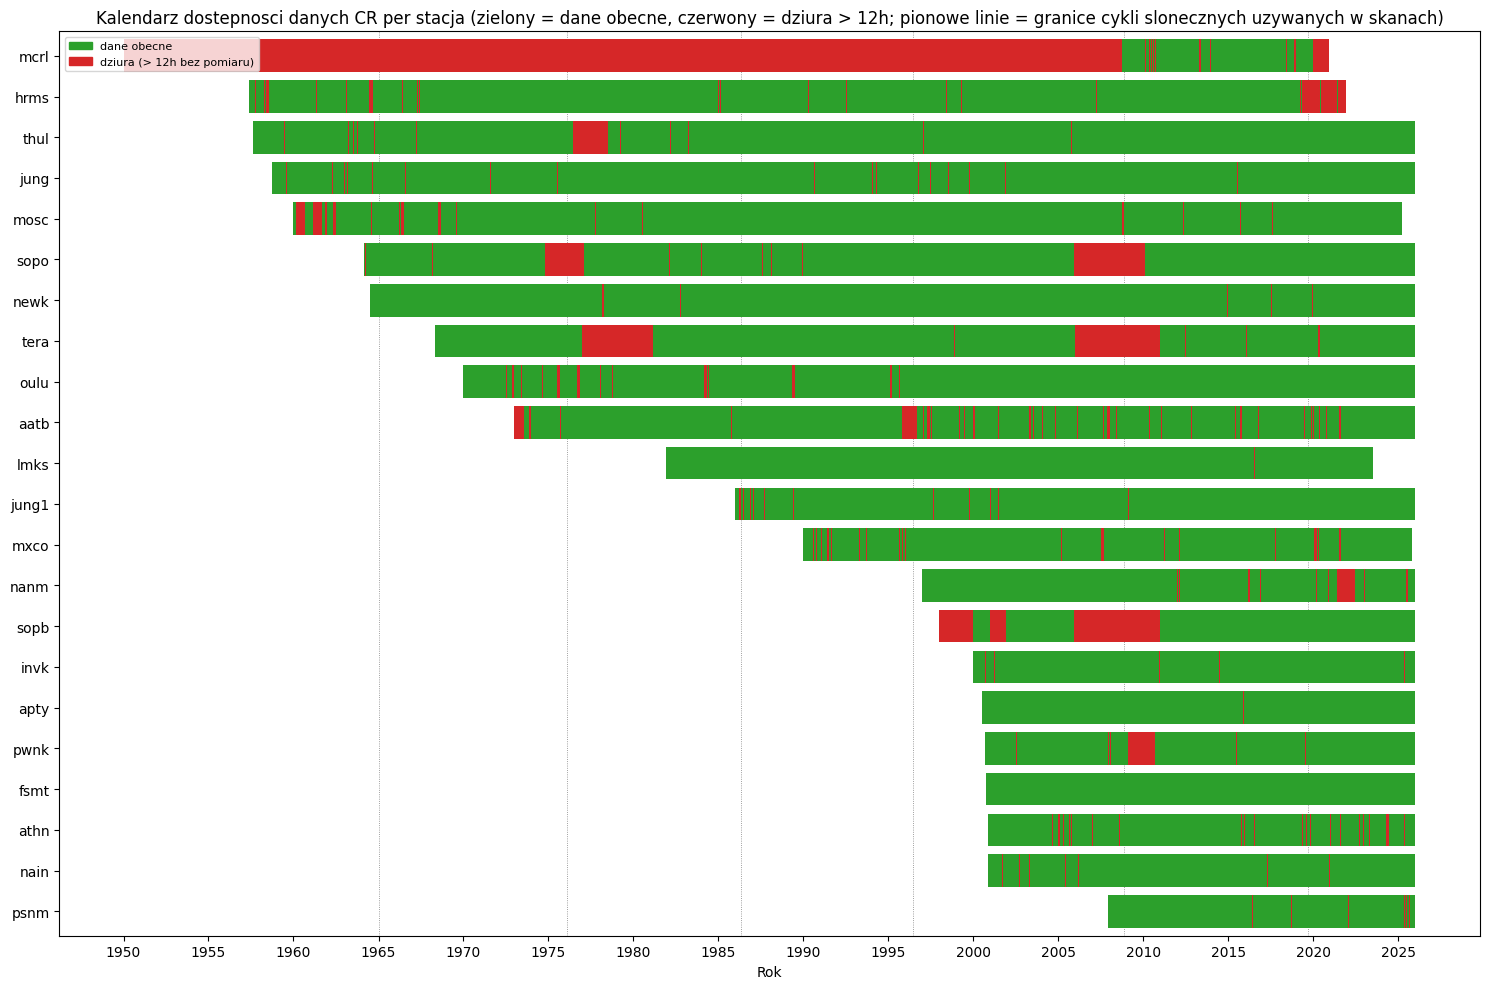

In [30]:
# KROK 5 (na prosbe Maćka - dokladniejszy wykres): "kalendarz dostepnosci"
# - jeden pasek na stacje na osi czasu (lata), zielony = dane obecne,
# czerwony = dziura (ten sam prog co w KROK 2/4: przerwa > 2x oczekiwanego
# kroku 6h = 12h). W przeciwienstwie do pojedynczej liczby completeness_pct
# pokazuje WPROST, KTORE lata/dekady brakuja, nie tylko ile % brakuje.
GAP_THRESHOLD_HOURS = 2 * RESOLUTION_HOURS


def find_gaps(raw_series, threshold_hours):
    valid = raw_series.dropna().sort_index()
    idx = valid.index
    if len(idx) < 2:
        return []
    diffs = idx[1:] - idx[:-1]
    mask = diffs > pd.Timedelta(hours=threshold_hours)
    return list(zip(idx[:-1][mask], idx[1:][mask]))


def to_mdate(ts):
    return mdates.date2num(ts.to_pydatetime())


station_order = completeness.sort_values("t_min")["station"].tolist()

fig, ax = plt.subplots(figsize=(15, 10))
for y, name in enumerate(station_order):
    s = cr_series[name]
    valid = s.dropna()
    if len(valid) == 0:
        continue
    t_min, t_max = valid.index.min(), valid.index.max()

    # baza: caly wlasny zasieg stacji - zielony ("dane obecne" domyslnie)
    ax.broken_barh(
        [(to_mdate(t_min), to_mdate(t_max) - to_mdate(t_min))],
        (y - 0.4, 0.8), facecolors="tab:green", edgecolor="none",
    )
    # dziury nadrukowane na wierzchu, na czerwono
    gaps = find_gaps(s, GAP_THRESHOLD_HOURS)
    if gaps:
        gap_bars = [(to_mdate(g0), to_mdate(g1) - to_mdate(g0)) for g0, g1 in gaps]
        ax.broken_barh(gap_bars, (y - 0.4, 0.8), facecolors="tab:red", edgecolor="none")

# pionowe linie = granice cykli slonecznych (ten sam podzial co w KROK 4 i
# w 20260826a.ipynb) - kontekst, ktore lata naleza do ktorego cyklu.
for cycle, t0 in CYCLE_START.items():
    ax.axvline(to_mdate(t0), color="gray", lw=0.6, ls=":", zorder=0)

ax.set_yticks(range(len(station_order)))
ax.set_yticklabels(station_order)
ax.set_ylim(-0.6, len(station_order) - 0.4)
ax.invert_yaxis()  # najstarsza stacja (najwczesniejszy t_min) u gory
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Rok")
ax.set_title(
    f"Kalendarz dostepnosci danych CR per stacja "
    f"(zielony = dane obecne, czerwony = dziura > {GAP_THRESHOLD_HOURS}h; "
    f"pionowe linie = granice cykli slonecznych uzywanych w skanach)"
)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["tab:green", "tab:red"]]
ax.legend(handles, ["dane obecne", f"dziura (> {GAP_THRESHOLD_HOURS}h bez pomiaru)"],
          loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_data_completeness_timeline.png", dpi=130, bbox_inches="tight")
plt.show()

In [31]:
# KROK 6 (na prosbe Maćka - jakosc danych, nie tylko kompletnosc): wszystkie
# stacje NM mierza to samo globalne zjawisko (modulacja promieniowania
# kosmicznego przez aktywnosc sloneczna, spadki Forbusha) - poziom
# bezwzgledny roznie sie miedzy stacjami (cutoff rigidity, wysokosc,
# rozmiar detektora), ale WZGLEDNE wahania w czasie powinny byc silnie
# skorelowane miedzy stacjami. Stacja, ktora nie zgadza sie z reszta sieci,
# to podejrzenie o zly odczyt/kalibracje/zle dane - nie bierze poprawki na
# lokalizacje (rozne cutoff rigidity daja rozna CZULOSC na modulacje, wiec
# nawet "dobra" stacja moze miec nizsza korelacje), ale grube bledy (zla
# stacja, przesuniecie czasowe, uszkodzony detektor) powinny wypasc jako
# wyrazne odstajace wartosci.
#
# Metoda: resample do wspolnej siatki dziennej -> znormalizowanie do
# WZGLEDNEJ anomalii (% odchylenia od wlasnej 365-dniowej ruchomej mediany
# stacji - usuwa roznice poziomu bezwzglednego I wlasny dlugoterminowy
# trend/dryf) -> korelacja Pearsona kazdej pary stacji na WSPOLNEJ czesci
# ich historii (min. 730 dni nakladania, inaczej NaN - zbyt malo danych na
# sensowna korelacje). Przekatna (stacja vs ona sama) wychodzi 1.0 -
# normalne, do kontroli poprawnosci macierzy.
WINDOW_DAYS = 365
MIN_OVERLAP_DAYS = 730


def relative_anomaly(raw_series, window_days=WINDOW_DAYS):
    daily = raw_series.resample("1D").mean()
    baseline = daily.rolling(window_days, center=True, min_periods=int(window_days * 0.25)).median()
    return (daily - baseline) / baseline * 100


names = sorted(cr_series.keys())
rel = {name: relative_anomaly(cr_series[name]) for name in names}

corr_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
overlap_days = pd.DataFrame(index=names, columns=names, dtype=float)
for i, a in enumerate(names):
    for b in names[i:]:
        sa, sb = rel[a].align(rel[b], join="inner")
        valid = sa.notna() & sb.notna()
        n = int(valid.sum())
        overlap_days.loc[a, b] = overlap_days.loc[b, a] = n
        r = sa[valid].corr(sb[valid]) if n >= MIN_OVERLAP_DAYS else np.nan
        corr_matrix.loc[a, b] = corr_matrix.loc[b, a] = r

corr_matrix.to_csv(f"{RESULTS_DIR}/station_cross_correlation.csv")
overlap_days.to_csv(f"{RESULTS_DIR}/station_cross_correlation_overlap_days.csv")

# Liczba par BEZ wystarczajacego nakladania - liczona TYLKO na faktycznych
# unikalnych parach (gorny trojkat bez przekatnej), nie na calej
# zamaskowanej macierzy (wczesniejsza wersja liczyla tez zamaskowane
# komorki dolnego trojkata/przekatnej jako "NaN" - dawalo bez sensu wiecej
# "brakujacych par" niz par w ogole).
n_pairs = len(names) * (len(names) - 1) // 2
triu_mask = np.triu(np.ones((len(names), len(names)), dtype=bool), k=1)
upper_vals = corr_matrix.to_numpy()[triu_mask]
n_nan_pairs = int(np.isnan(upper_vals).sum())
print(f"Policzono korelacje dla {len(names)} stacji ({n_pairs} par), prog min. nakladania: {MIN_OVERLAP_DAYS} dni.")
print(f"Pary bez wystarczajacego nakladania (NaN): {n_nan_pairs} z {n_pairs}")

Policzono korelacje dla 22 stacji (231 par), prog min. nakladania: 730 dni.
Pary bez wystarczajacego nakladania (NaN): 0 z 231


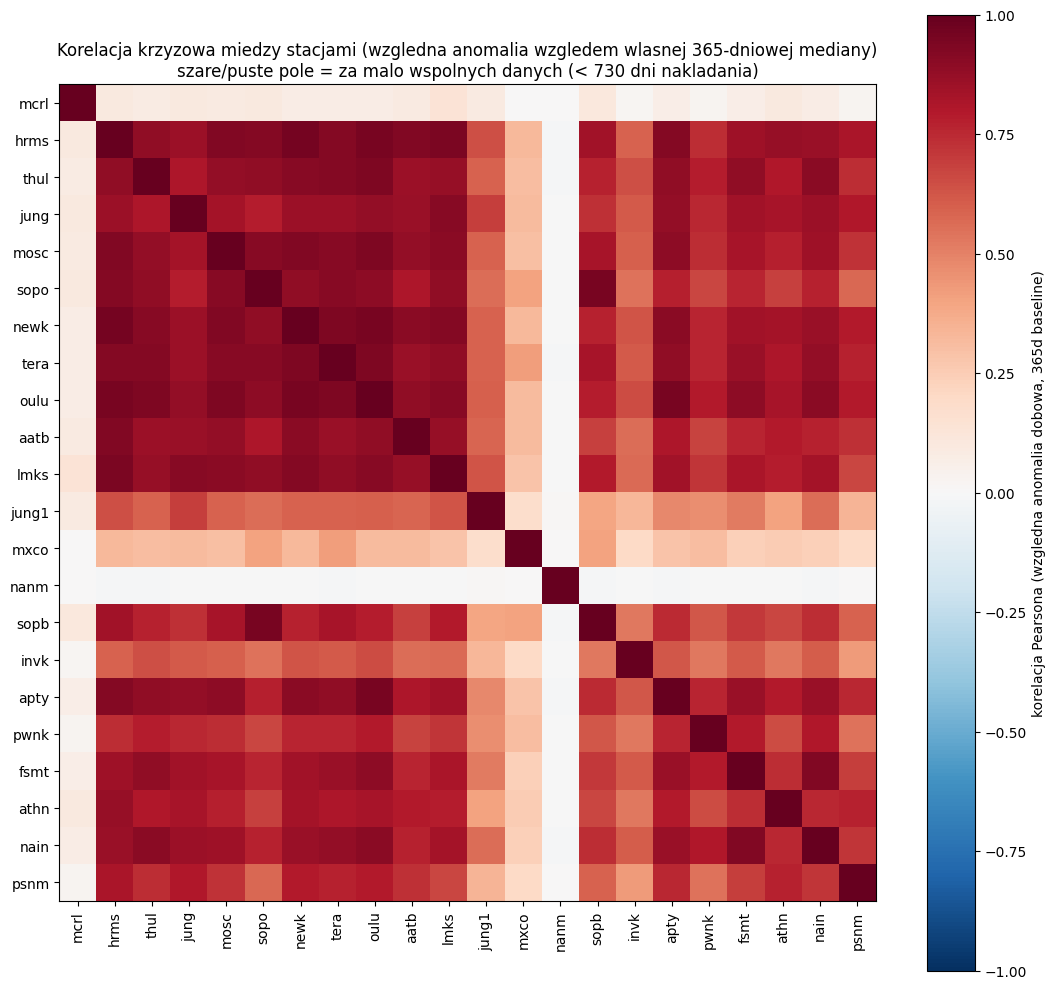

In [32]:
# KROK 7: heatmapa macierzy korelacji (22x22) - stacje posortowane tak samo
# jak w KROK 5 (wg t_min) dla spojnosci z reszta notebooka.
order = completeness.sort_values("t_min")["station"].tolist()
corr_ordered = corr_matrix.reindex(index=order, columns=order)

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(corr_ordered.to_numpy(dtype=float), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=90)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
fig.colorbar(im, ax=ax, label="korelacja Pearsona (wzgledna anomalia dobowa, 365d baseline)")
ax.set_title(
    "Korelacja krzyzowa miedzy stacjami (wzgledna anomalia wzgledem wlasnej "
    "365-dniowej mediany)\nszare/puste pole = za malo wspolnych danych "
    f"(< {MIN_OVERLAP_DAYS} dni nakladania)"
)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_cross_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

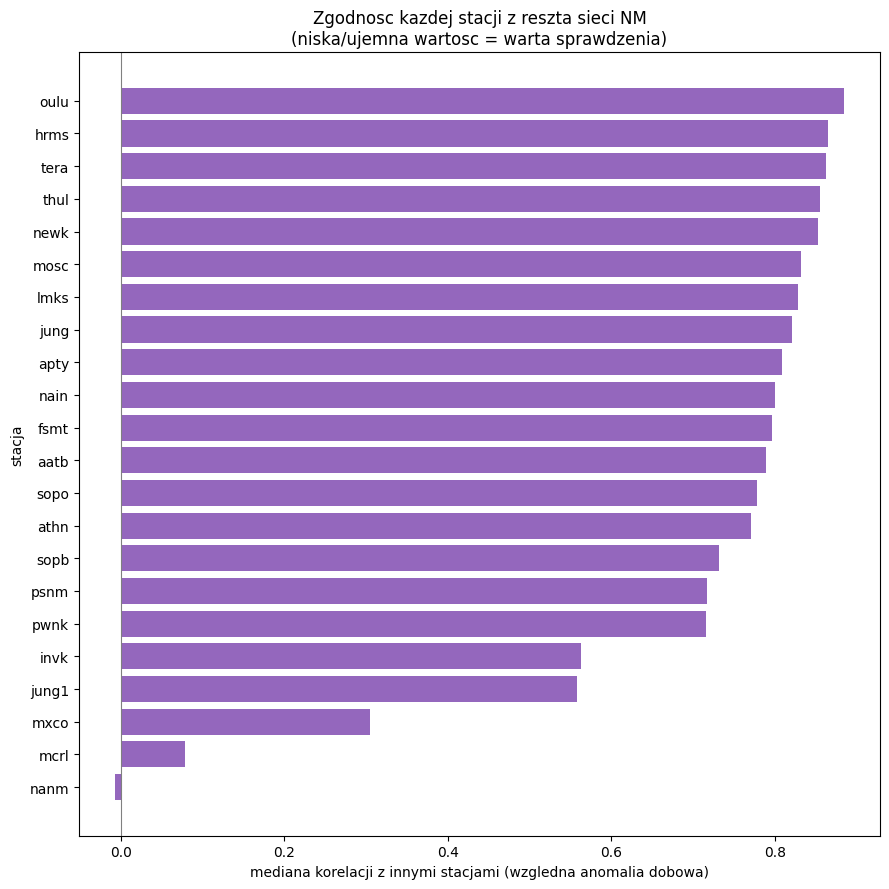

station  median_corr_with_others  n_comparable_stations  min_corr
   nanm                -0.006696                     21 -0.010735
   mcrl                 0.078100                     21  0.001902
   mxco                 0.304316                     21  0.000146
  jung1                 0.557319                     21  0.010898
   invk                 0.562913                     21 -0.006368
   pwnk                 0.715861                     21 -0.007651
   psnm                 0.717363                     21  0.001078
   sopb                 0.731524                     21 -0.010735
   athn                 0.771013                     21 -0.003844
   sopo                 0.777573                     21 -0.006696
   aatb                 0.789368                     21 -0.001269
   fsmt                 0.796069                     21 -0.007454
   nain                 0.799775                     21 -0.008010
   apty                 0.807922                     21 -0.009562
   jung   

In [33]:
# KROK 8: pojedyncza liczba per stacja - "zgodnosc z siecia" = mediana
# korelacji z WSZYSTKIMI innymi stacjami majacymi wystarczajace nakladanie
# (bez przekatnej). Niska/ujemna wartosc = kandydat do sprawdzenia (zla
# kalibracja, przesuniecie czasowe, uszkodzony detektor) - PAMIETAJ: to
# nie bierze poprawki na lokalizacje/cutoff rigidity, wiec nie jest to
# dowod same w sobie, tylko sito do dalszego sprawdzenia.
network_agreement = []
for name in names:
    others = corr_matrix.loc[name].drop(index=name).dropna()
    network_agreement.append(dict(
        station=name, median_corr_with_others=others.median(),
        n_comparable_stations=len(others),
        min_corr=others.min() if len(others) else np.nan,
    ))
network_agreement = pd.DataFrame(network_agreement).sort_values("median_corr_with_others")
network_agreement.to_csv(f"{RESULTS_DIR}/station_network_agreement.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(network_agreement["station"], network_agreement["median_corr_with_others"], color="tab:purple")
ax.set_xlabel("mediana korelacji z innymi stacjami (wzgledna anomalia dobowa)")
ax.set_ylabel("stacja")
ax.axvline(0, color="gray", lw=0.8)
ax.set_title("Zgodnosc kazdej stacji z reszta sieci NM\n(niska/ujemna wartosc = warta sprawdzenia)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_network_agreement.png", dpi=120, bbox_inches="tight")
plt.show()

pd.set_option("display.width", 160)
print(network_agreement.to_string(index=False))

In [34]:
# KROK 9 (inny pomysl - integralnosc surowych danych): dwie proste, tanie
# kontrole niezalezne od korelacji miedzy stacjami:
#   (a) wartosci <= 0 - tempo zliczen detektora fizycznie nie moze byc
#       ujemne ani zerowe (poza calkowitym brakiem danych, ktory powinien
#       byc NaN, nie 0) - obecnosc takich wartosci to sygnal bledu parsera
#       /eksportu NMDB, nie zjawiska fizycznego.
#   (b) "zaciecie" czujnika - dlugie serie IDENTYCZNYCH kolejnych odczytow.
#       Prawdziwe tempo zliczen ma statystyczny szum (Poissonowski) - dlugi
#       plaski odcinek sugeruje powtorzona/zamrozona/interpolowana wartosc
#       zamiast realnego pomiaru.
MIN_STUCK_RUN = 20  # >=20 kolejnych identycznych odczytow 6h = >=5 dni plasko
WORST_STUCK_RUNS_COLS = ["station", "value", "start", "end", "n_readings", "run_days"]


def stuck_runs(raw_series, min_run_length=MIN_STUCK_RUN):
    valid = raw_series.dropna()
    if len(valid) < min_run_length:
        return pd.DataFrame(columns=["value", "start", "end", "n"])
    vals = valid.to_numpy()
    ts = valid.index.to_numpy()
    change = np.r_[True, vals[1:] != vals[:-1]]
    group_id = np.cumsum(change)
    # "ts" jako zwykla kolumna (nie index) - omija niejednoznacznosc nazwy
    # indeksu po reset_index() (indeksy loaderow tego repo nazywaja sie
    # "datetime", nie domyslnie "index").
    df = pd.DataFrame({"value": vals, "ts": ts, "group": group_id})
    runs = df.groupby("group").agg(
        value=("value", "first"), start=("ts", "first"), end=("ts", "last"), n=("value", "size"),
    )
    return runs[runs["n"] >= min_run_length].sort_values("n", ascending=False)


integrity_rows = []
worst_stuck_runs = []
for name, s in cr_series.items():
    valid = s.dropna()
    n_nonpositive = int((valid <= 0).sum())
    runs = stuck_runs(s)
    if len(runs):
        top = runs.iloc[0]
        worst_stuck_runs.append(dict(station=name, value=top["value"], start=top["start"],
                                      end=top["end"], n_readings=int(top["n"]),
                                      run_days=(pd.Timestamp(top["end"]) - pd.Timestamp(top["start"])).total_seconds() / 86400))
    integrity_rows.append(dict(
        station=name, n_nonpositive=n_nonpositive, n_stuck_runs=len(runs),
        longest_stuck_run_readings=int(runs["n"].max()) if len(runs) else 0,
    ))

integrity = pd.DataFrame(integrity_rows).sort_values("longest_stuck_run_readings", ascending=False)
integrity.to_csv(f"{RESULTS_DIR}/station_data_integrity.csv", index=False)

# Zabezpieczenie na wypadek, gdyby ZADNA stacja nie miala zadnego "zaciecia"
# (worst_stuck_runs byloby wtedy pusta lista -> DataFrame bez kolumn ->
# sort_values("run_days") rzucilby KeyError).
if worst_stuck_runs:
    worst_stuck_runs = pd.DataFrame(worst_stuck_runs).sort_values("run_days", ascending=False)
else:
    worst_stuck_runs = pd.DataFrame(columns=WORST_STUCK_RUNS_COLS)
worst_stuck_runs.to_csv(f"{RESULTS_DIR}/station_longest_stuck_runs.csv", index=False)

pd.set_option("display.width", 160)
print("=== Wartosci <= 0 i liczba 'zacietych' serii per stacja (prog: >= "
      f"{MIN_STUCK_RUN} identycznych odczytow z rzedu) ===")
print(integrity.to_string(index=False))
print(f"\n=== Najdluzsze pojedyncze 'zaciecia' (top {min(10, len(worst_stuck_runs))}) ===")
print(worst_stuck_runs.head(10).to_string(index=False) if len(worst_stuck_runs) else "(brak zacietych serii u zadnej stacji)")

=== Wartosci <= 0 i liczba 'zacietych' serii per stacja (prog: >= 20 identycznych odczytow z rzedu) ===
station  n_nonpositive  n_stuck_runs  longest_stuck_run_readings
   nanm              0             5                         128
   mcrl            285             5                         117
   thul              0             0                           0
   lmks              0             0                           0
   mosc              0             0                           0
   oulu              0             0                           0
   sopb              6             0                           0
   apty              0             0                           0
  jung1              0             0                           0
   sopo              6             0                           0
   newk              0             0                           0
   pwnk              3             0                           0
   fsmt              0             0               

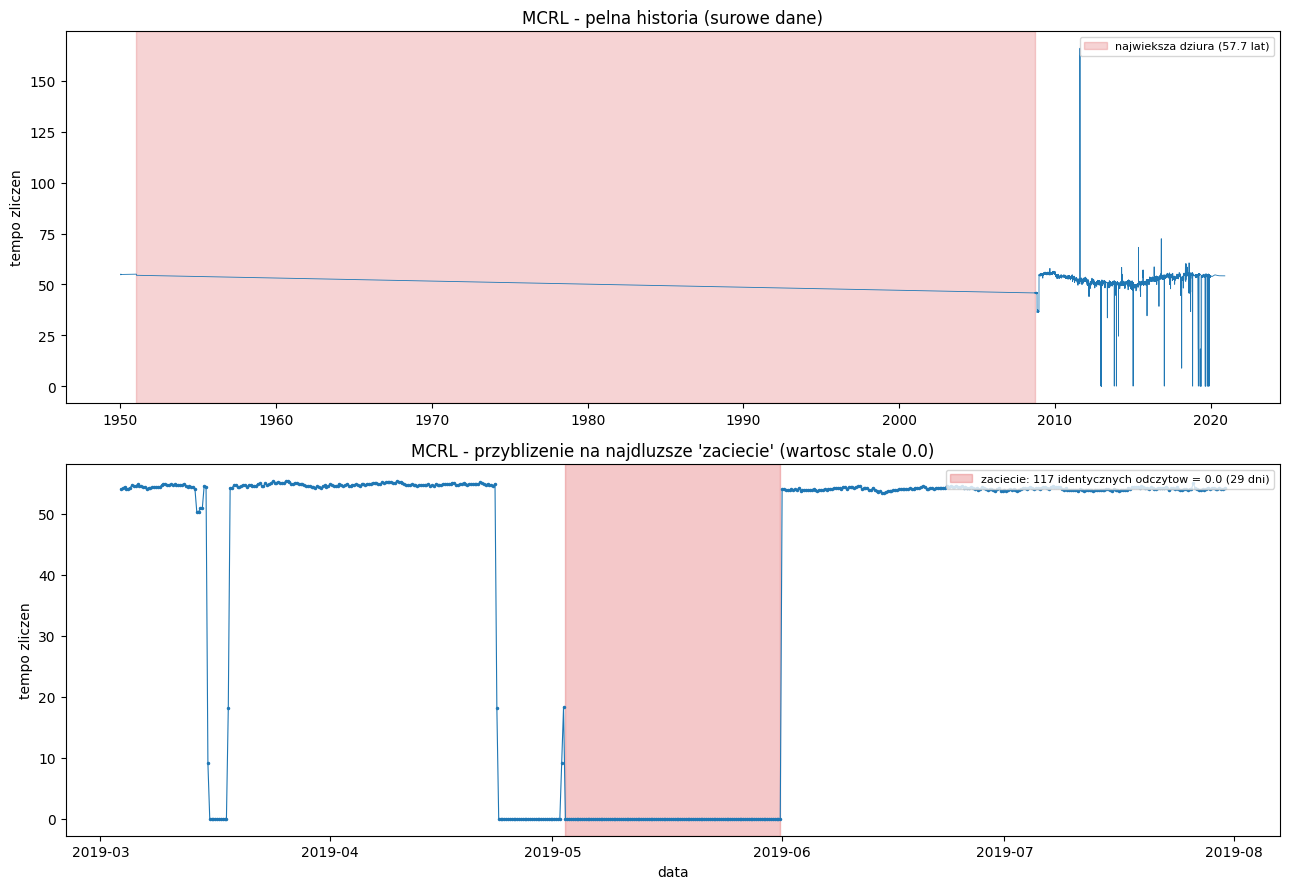

In [35]:
# KROK 10 (na prosbe Maćka - wykresy "dowodowe" do dziennika): MCRL -
# pelna historia z zaznaczona najwieksza dziura + przyblizenie na
# najdluzsze "zaciecie" (wartosc stale 0.0) - wizualny dowod na liczby z
# podsumowania (285 wartosci <=0, dziura 57,7 roku, 117 identycznych
# odczytow = 0.0 przez 29 dni).
mcrl_valid = cr_series["mcrl"].dropna().sort_index()
mcrl_gaps = find_gaps(cr_series["mcrl"], GAP_THRESHOLD_HOURS)
mcrl_stuck = stuck_runs(cr_series["mcrl"])

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

ax = axes[0]
ax.plot(mcrl_valid.index, mcrl_valid.values, color="tab:blue", lw=0.6)
if mcrl_gaps:
    g0, g1 = max(mcrl_gaps, key=lambda g: g[1] - g[0])
    ax.axvspan(g0, g1, color="tab:red", alpha=0.2,
               label=f"najwieksza dziura ({(g1 - g0).days / 365.25:.1f} lat)")
ax.set_title("MCRL - pelna historia (surowe dane)")
ax.set_ylabel("tempo zliczen")
ax.legend(fontsize=8, loc="upper right")

ax2 = axes[1]
top_run = mcrl_stuck.iloc[0]
run_start, run_end = pd.Timestamp(top_run["start"]), pd.Timestamp(top_run["end"])
zoom = mcrl_valid[(mcrl_valid.index >= run_start - pd.Timedelta(days=60)) &
                   (mcrl_valid.index <= run_end + pd.Timedelta(days=60))]
ax2.plot(zoom.index, zoom.values, color="tab:blue", marker=".", ms=3, lw=0.8)
ax2.axvspan(run_start, run_end, color="tab:red", alpha=0.25,
            label=f"zaciecie: {int(top_run['n'])} identycznych odczytow = "
                  f"{top_run['value']:.1f} ({(run_end - run_start).days} dni)")
ax2.set_title("MCRL - przyblizenie na najdluzsze 'zaciecie' (wartosc stale 0.0)")
ax2.set_ylabel("tempo zliczen")
ax2.set_xlabel("data")
ax2.legend(fontsize=8, loc="upper right")

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/mcrl_quality_issues.png", dpi=130, bbox_inches="tight")
plt.show()

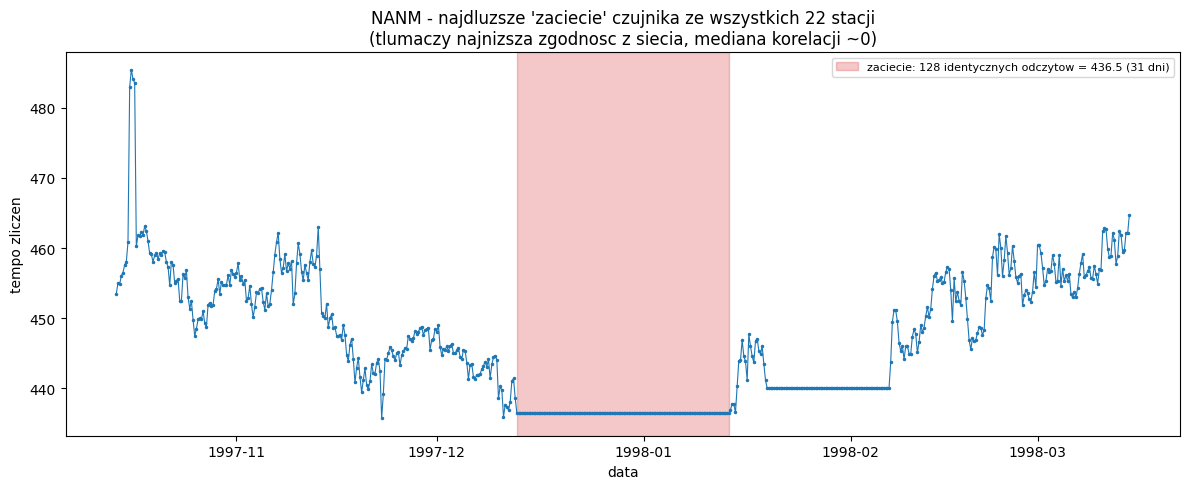

In [36]:
# KROK 11: NANM - przyblizenie na jej najdluzsze "zaciecie" (128
# identycznych odczytow, rekord ze wszystkich stacji) - wizualny dowod
# tlumaczacy, dlaczego NANM ma najnizsza zgodnosc z siecia ze wszystkich
# 22 stacji (KROK 8), mimo przyzwoitej kompletnosci (93,9%, KROK 2) i
# braku wartosci <=0.
nanm_valid = cr_series["nanm"].dropna().sort_index()
nanm_stuck = stuck_runs(cr_series["nanm"])
top_run = nanm_stuck.iloc[0]
run_start, run_end = pd.Timestamp(top_run["start"]), pd.Timestamp(top_run["end"])
zoom = nanm_valid[(nanm_valid.index >= run_start - pd.Timedelta(days=60)) &
                   (nanm_valid.index <= run_end + pd.Timedelta(days=60))]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(zoom.index, zoom.values, color="tab:blue", marker=".", ms=3, lw=0.8)
ax.axvspan(run_start, run_end, color="tab:red", alpha=0.25,
           label=f"zaciecie: {int(top_run['n'])} identycznych odczytow = "
                 f"{top_run['value']:.1f} ({(run_end - run_start).days} dni)")
ax.set_title("NANM - najdluzsze 'zaciecie' czujnika ze wszystkich 22 stacji\n"
             "(tlumaczy najnizsza zgodnosc z siecia, mediana korelacji ~0)")
ax.set_ylabel("tempo zliczen")
ax.set_xlabel("data")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/nanm_quality_issue.png", dpi=130, bbox_inches="tight")
plt.show()

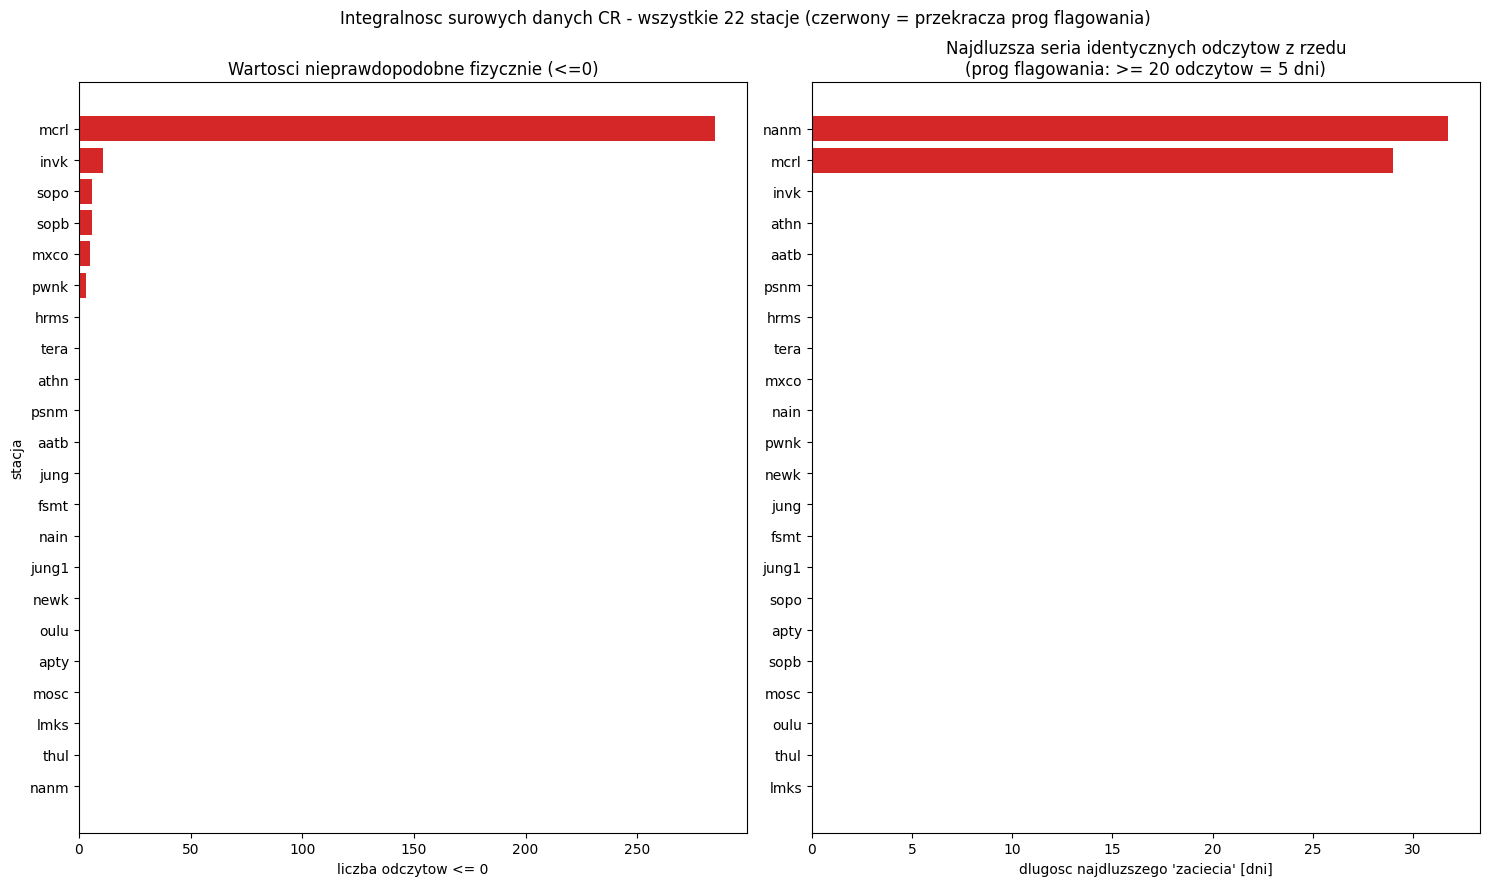

In [37]:
# KROK 12 (na prosbe Maćka - integralnosc danych dla WSZYSTKICH stacji,
# nie tylko tych juz zdiagnozowanych jako podejrzane): dwa panele obok
# siebie, kazda z 22 stacji, posortowane niezaleznie wg wlasnej miary -
# (a) liczba wartosci <=0, (b) dlugosc najdluzszego "zaciecia" w dniach.
# To ten sam KROK 9 (integrity/worst_stuck_runs), tylko jako wykres
# zamiast tabeli tekstowej, dla pelnego zestawu stacji na raz.
run_days_by_station = worst_stuck_runs.set_index("station")["run_days"] if len(worst_stuck_runs) else pd.Series(dtype=float)
integrity_plot = integrity.copy()
integrity_plot["longest_stuck_run_days"] = integrity_plot["station"].map(run_days_by_station).fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(15, 9))

left = integrity_plot.sort_values("n_nonpositive", ascending=True)
colors_left = ["tab:red" if v > 0 else "tab:blue" for v in left["n_nonpositive"]]
axes[0].barh(left["station"], left["n_nonpositive"], color=colors_left)
axes[0].set_xlabel("liczba odczytow <= 0")
axes[0].set_title("Wartosci nieprawdopodobne fizycznie (<=0)")
axes[0].set_ylabel("stacja")

right = integrity_plot.sort_values("longest_stuck_run_days", ascending=True)
colors_right = ["tab:red" if v >= 5 else "tab:blue" for v in right["longest_stuck_run_days"]]
axes[1].barh(right["station"], right["longest_stuck_run_days"], color=colors_right)
axes[1].set_xlabel("dlugosc najdluzszego 'zaciecia' [dni]")
axes[1].set_title(f"Najdluzsza seria identycznych odczytow z rzedu\n(prog flagowania: >= {MIN_STUCK_RUN} odczytow = 5 dni)")

fig.suptitle("Integralnosc surowych danych CR - wszystkie 22 stacje (czerwony = przekracza prog flagowania)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_data_integrity.png", dpi=120, bbox_inches="tight")
plt.show()

In [38]:
# PODSUMOWANIE (do dziennika 20260826.txt): najwazniejsze fakty liczbowe do
# przekazania Homoli na pytanie #4 z 24.08.
print("=== Stacje wciaz na fallbacku full6h (tylko 2005-2025, NIE pelna historia) ===")
short = completeness[completeness["source"].str.contains("TYLKO", na=False)]
print(short[["station", "span_years", "completeness_pct"]].to_string(index=False) if len(short) else "(brak)")

print("\n=== Najnizsza kompletnosc globalna (dolne 5) ===")
print(completeness.nsmallest(5, "completeness_pct")[["station", "span_years", "completeness_pct", "n_gaps", "longest_gap_days"]].to_string(index=False))

print("\n=== Stacje, gdzie faktyczny pierwszy pomiar jest wyraznie pozniej niz nominalny pierwszy rok NMDB (>2 lata) ===")
late_start = completeness[completeness["years_shorter_than_nominal"] > 2]
print(late_start[["station", "nominal_first_year", "actual_first_year", "years_shorter_than_nominal"]].to_string(index=False) if len(late_start) else "(brak)")

print("\n=== Najnizsza zgodnosc z siecia (korelacja wzglednej anomalii, dolne 5) ===")
print(network_agreement.head(5)[["station", "median_corr_with_others", "n_comparable_stations", "min_corr"]].to_string(index=False))

print("\n=== Stacje z podejrzanymi wartosciami <=0 lub dlugimi 'zacieciami' (>= "
      f"{MIN_STUCK_RUN} identycznych odczytow z rzedu) ===")
suspect = integrity[(integrity["n_nonpositive"] > 0) | (integrity["longest_stuck_run_readings"] >= MIN_STUCK_RUN)]
print(suspect.to_string(index=False) if len(suspect) else "(brak)")

print("\nZAKRES: obiektywna kompletnosc/jakosc danych (odpowiedz na prosbe Homoli #4) +")
print("korelacja miedzy stacjami jako sito na grube bledy jakosci (pomysl Maćka, 26.08) +")
print("podstawowa integralnosc surowych danych (wartosci <=0, 'zaciecia' czujnika).")
print("UWAGA: korelacja NIE bierze poprawki na lokalizacje/cutoff rigidity - niska")
print("wartosc to kandydat do sprawdzenia, nie dowod bledu sam w sobie.")
print("Pytanie #5 (dlaczego niektore stacje sa 'wyblakle' na heatmapach mimo obecnosci")
print("danych) NIE jest tu analizowane - do zrobienia jako osobny watek pozniej.")

=== Stacje wciaz na fallbacku full6h (tylko 2005-2025, NIE pelna historia) ===
(brak)

=== Najnizsza kompletnosc globalna (dolne 5) ===
station  span_years  completeness_pct  n_gaps  longest_gap_days
   mcrl   70.880903         14.659418     119          21074.75
   sopb   28.002053         70.991396      27           1864.25
   tera   57.669405         83.270034      66           1520.25
   sopo   61.836413         88.934517      91           1534.00
   pwnk   25.297057         92.670455      43            584.75

=== Stacje, gdzie faktyczny pierwszy pomiar jest wyraznie pozniej niz nominalny pierwszy rok NMDB (>2 lata) ===
(brak)

=== Najnizsza zgodnosc z siecia (korelacja wzglednej anomalii, dolne 5) ===
station  median_corr_with_others  n_comparable_stations  min_corr
   nanm                -0.006696                     21 -0.010735
   mcrl                 0.078100                     21  0.001902
   mxco                 0.304316                     21  0.000146
  jung1            